## Imports

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
import numpy as np
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

## HCD ADU Dataset

In [97]:
adu_df = pd.read_csv('data/HCD_ADUs_2024_20260225.csv', low_memory=False)
adu_df

,_id,JURISDICTION,COUNTY,YEAR,PRIOR APN,APN,STREET ADDRESS,PROJECT NAME,JURS_TRACKING_ID,STRUCTURE TYPE,...,Total Moderate Income Units Permitted,Total Above Moderate Income Units Permitted,Total Permitted Income Units,Very Low Income Unit,Low Income Unit,Moderate Income Unit,Above Moderate Income Unit,AFFORDABILITY,Unit Year,Point
0,558,SAN DIEGO COUNTY,San Diego,2021,NaN,2.384012e+09,1038 VEREDA CALLADA ADU,NaN,PDS2021-RESACC-000056,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.090564 33.081636)
1,1925,CHULA VISTA,San Diego,2024,NaN,6.191412e+09,1134 ALPINE AVENUE,NaN,BR23-0330,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2024,POINT (-117.0619139 32.61454169)
2,2081,CHULA VISTA,San Diego,2021,NaN,5.754331e+09,1143 HILLTOP DRIVE,NaN,BR20-0087,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.056031 32.615687)
3,2514,VISTA,San Diego,2021,169-080-69-00,1.690807e+09,1188 ACADEMY LANE #1,NaN,NaN,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.251376 33.180839)
4,3405,IMPERIAL BEACH,San Diego,2022,NaN,6.330923e+09,1254 13TH ST UNIT: #02,ADU,BLDR-22-1049,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2022,POINT (-117.106138 32.573857)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12843,2729,SAN DIEGO,San Diego,2023,NaN,6.311905e+09,1207 ILEXEY AVENUE,General-Standard-Combination Building Permit:1...,PMT-3229657,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2023,POINT (-117.044398 32.574953)
12844,19039,LA MESA,San Diego,2024,NaN,4.750800e+09,4231 OLIVE AVENUE,NaN,2023-2057,Accessory Dwelling Unit,...,0,0,1,False,True,False,False,Low,2024,POINT (-117.0340038 32.75594722)
12845,18928,OCEANSIDE,San Diego,2023,NaN,1.662350e+09,4204 THOMAS STREET,NEW ATTACHED ADU ABOVE GARAGE,BLDG23-1611,Accessory Dwelling Unit,...,1,0,1,False,False,True,False,Moderate,2023,POINT (-117.281616 33.197343)
12846,7629,SAN DIEGO,San Diego,2023,NaN,6.340920e+09,1695 SATURN BL,General-Expedite-Building Construction:1695/Sa...,PMT-3170311,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2023,POINT (-117.092713 32.566539)


In [98]:
print(adu_df.shape)
print(adu_df.info())
print(adu_df.describe())

(12848, 66)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12848 entries, 0 to 12847
Data columns (total 66 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   _id                                          12848 non-null  int64  
 1   JURISDICTION                                 12848 non-null  object 
 2   COUNTY                                       12848 non-null  object 
 3   YEAR                                         12848 non-null  int64  
 4   PRIOR APN                                    1126 non-null   object 
 5   APN                                          12365 non-null  float64
 6   STREET ADDRESS                               12847 non-null  object 
 7   PROJECT NAME                                 6169 non-null   object 
 8   JURS_TRACKING_ID                             12503 non-null  object 
 9   STRUCTURE TYPE                               12848 non-null 

In [99]:
adu_df.isnull().mean().sort_values(ascending=False) * 100

DENSITY_BONUS_INCENTIVES           97.454857
DENSITY_BONUS_RECEIVE_REDUCTION    97.454857
NOTES                              94.995330
DR_TYPE                            94.894147
ENT_APPROVE_DT1                    94.185866
                                     ...    
CO_VLOW_INCOME_NDR                  0.000000
CO_LOW_INCOME_DR                    0.000000
CO_LOW_INCOME_NDR                   0.000000
JURISDICTION                        0.000000
CO_MOD_INCOME_DR                    0.000000
Length: 66, dtype: float64

In [100]:
drop_cols = ['DENSITY_BONUS_RECEIVE_REDUCTION', 'DENSITY_BONUS_INCENTIVES',
             'NOTES', 'DR_TYPE', 'TERM_AFF_DR', 'PRIOR APN', 'PROJECT NAME']
adu_df = adu_df.drop(columns=drop_cols, errors='ignore')
adu_df.head()

,_id,JURISDICTION,COUNTY,YEAR,APN,STREET ADDRESS,JURS_TRACKING_ID,STRUCTURE TYPE,TENURE,VLOW_INCOME_DR,...,Total Moderate Income Units Permitted,Total Above Moderate Income Units Permitted,Total Permitted Income Units,Very Low Income Unit,Low Income Unit,Moderate Income Unit,Above Moderate Income Unit,AFFORDABILITY,Unit Year,Point
0,558,SAN DIEGO COUNTY,San Diego,2021,2.384012e+09,1038 VEREDA CALLADA ADU,PDS2021-RESACC-000056,Accessory Dwelling Unit,Owner,0,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.090564 33.081636)
1,1925,CHULA VISTA,San Diego,2024,6.191412e+09,1134 ALPINE AVENUE,BR23-0330,Accessory Dwelling Unit,Renter,0,...,0,1,1,False,False,False,True,Above Moderate,2024,POINT (-117.0619139 32.61454169)
2,2081,CHULA VISTA,San Diego,2021,5.754331e+09,1143 HILLTOP DRIVE,BR20-0087,Accessory Dwelling Unit,Renter,0,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.056031 32.615687)
3,2514,VISTA,San Diego,2021,1.690807e+09,1188 ACADEMY LANE #1,NaN,Accessory Dwelling Unit,Renter,0,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.251376 33.180839)
4,3405,IMPERIAL BEACH,San Diego,2022,6.330923e+09,1254 13TH ST UNIT: #02,BLDR-22-1049,Accessory Dwelling Unit,Renter,0,...,0,1,1,False,False,False,True,Above Moderate,2022,POINT (-117.106138 32.573857)


## Data Cleaning & Preprocessing

In [101]:
zero_var_cols = [
    'COUNTY', 'STRUCTURE TYPE', 'State',
    'VLOW_INCOME_DR', 'LOW_INCOME_DR', 'MOD_INCOME_DR',
    'CO_VLOW_INCOME_DR', 'CO_LOW_INCOME_DR',
    'DEM_OR_DES_UNITS', 'DEM_DES_UNITS_OWN_RENT'
]
adu_df = adu_df.drop(columns=zero_var_cols, errors='ignore')
print(f'Shape after dropping zero-variance cols: {adu_df.shape}')

Shape after dropping zero-variance cols: (12848, 49)


In [102]:
date_cols = ['ENT_APPROVE_DT1', 'BP_ISSUE_DT1', 'CO_ISSUE_DT1']
for col in date_cols:
    adu_df[col] = pd.to_datetime(adu_df[col], errors='coerce')
print('Date columns parsed:')
for col in date_cols:
    print(f'  {col}: {adu_df[col].notna().sum()} non-null')

Date columns parsed:
  ENT_APPROVE_DT1: 747 non-null
  BP_ISSUE_DT1: 12848 non-null
  CO_ISSUE_DT1: 1362 non-null


In [103]:
adu_df['APN'] = adu_df['APN'].dropna().apply(lambda x: str(int(x)))
print('APN sample:', adu_df['APN'].head(3).tolist())

APN sample: ['2384011600', '6191412100', '5754330900']


In [104]:
adu_df['INFILL_UNITS'] = adu_df['INFILL_UNITS'].map({'Y': True, 'N': False, '0': False})
print(adu_df['INFILL_UNITS'].value_counts(dropna=False))

INFILL_UNITS
False    6790
True     6058
Name: count, dtype: int64


In [105]:
adu_df['APPROVE_SB35'] = adu_df['APPROVE_SB35'].apply(lambda x: False if pd.isna(x) or x in ('N','NONE') else True)
print(adu_df['APPROVE_SB35'].value_counts())

APPROVE_SB35
False    12844
True         4
Name: count, dtype: int64


In [106]:
coords = adu_df['Point'].str.extract(r'POINT \((-?\d+\.\d+) (-?\d+\.\d+)\)')
adu_df['LON'] = pd.to_numeric(coords[0])
adu_df['LAT'] = pd.to_numeric(coords[1])
adu_df = adu_df.drop(columns=['Point'])
print(f'Missing coords: {adu_df["LAT"].isna().sum()}')

Missing coords: 37


In [107]:
adu_df['fin_assist'] = adu_df['FIN_ASSIST_NAME'] != 'Not Receiving Financial Assistance'
adu_df = adu_df.drop(columns=['FIN_ASSIST_NAME'])
print(adu_df['fin_assist'].value_counts())

fin_assist
False    12237
True       611
Name: count, dtype: int64


In [108]:
adu_df['NO_FA_DR'] = adu_df['NO_FA_DR'].fillna('Unknown')
print('NO_FA_DR nulls:', adu_df['NO_FA_DR'].isna().sum())

NO_FA_DR nulls: 0


In [109]:
adu_df['has_entitlement'] = adu_df['NO_ENTITLEMENTS'] > 0
adu_df['has_bp']          = adu_df['NO_BUILDING_PERMITS'] > 0
adu_df['has_co']          = adu_df['NO_OTHER_FORMS_OF_READINESS'] > 0
print(f'BP: {adu_df["has_bp"].sum():,}  |  Entitlement: {adu_df["has_entitlement"].sum():,}  |  CO: {adu_df["has_co"].sum():,}')

BP: 12,848  |  Entitlement: 747  |  CO: 1,362


In [110]:
print(f'Final shape: {adu_df.shape[0]:,} rows x {adu_df.shape[1]} columns')
nulls = adu_df.isnull().sum()
print(nulls[nulls>0].sort_values(ascending=False))

Final shape: 12,848 rows x 53 columns
ENT_APPROVE_DT1     12101
CO_ISSUE_DT1        11486
APN                   483
JURS_TRACKING_ID      345
LON                    37
LAT                    37
STREET ADDRESS          1
dtype: int64


## Exploratory Data Analysis

In [111]:
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})
BLUE='#2563eb'; GRAY='#64748b'; AMBER='#f59e0b'; GREEN='#16a34a'; RED='#dc2626'

### Chart 1 — ADU Permits by Year

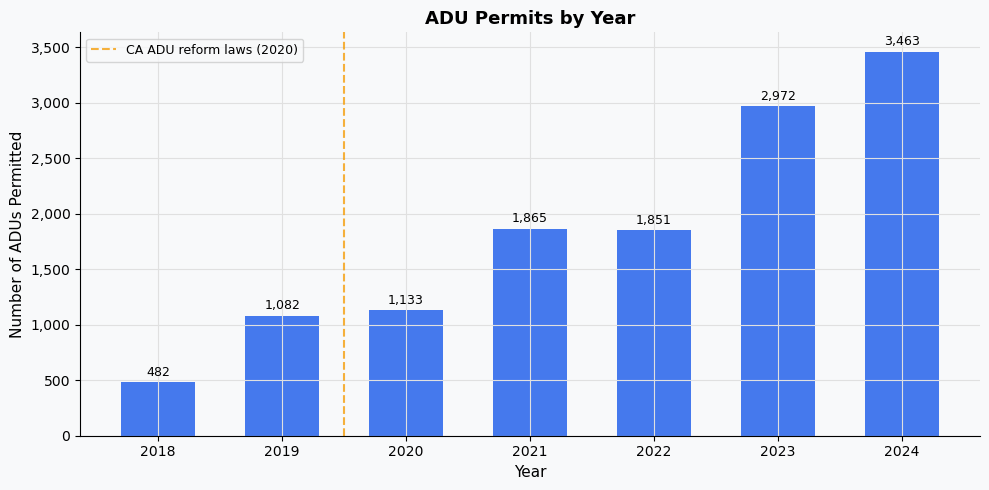

In [112]:
by_year = adu_df['YEAR'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(by_year.index, by_year.values, color=BLUE, alpha=0.85, width=0.6)
for bar, val in zip(bars, by_year.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.axvline(2019.5, color=AMBER, linestyle='--', linewidth=1.5, alpha=0.8, label='CA ADU reform laws (2020)')
ax.legend(fontsize=9)
ax.set_title('ADU Permits by Year', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Number of ADUs Permitted')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

**Interpretation:** ADU permitting in San Diego County nearly 7x from 2018 to 2024. The steepest jump follows California's 2020 ADU reform laws (SB 13, AB 68, AB 881), which streamlined approvals, eliminated owner-occupancy requirements, and reduced fees. Growth continues through 2024 with no plateau.

### Chart 2 — Affordability Breakdown

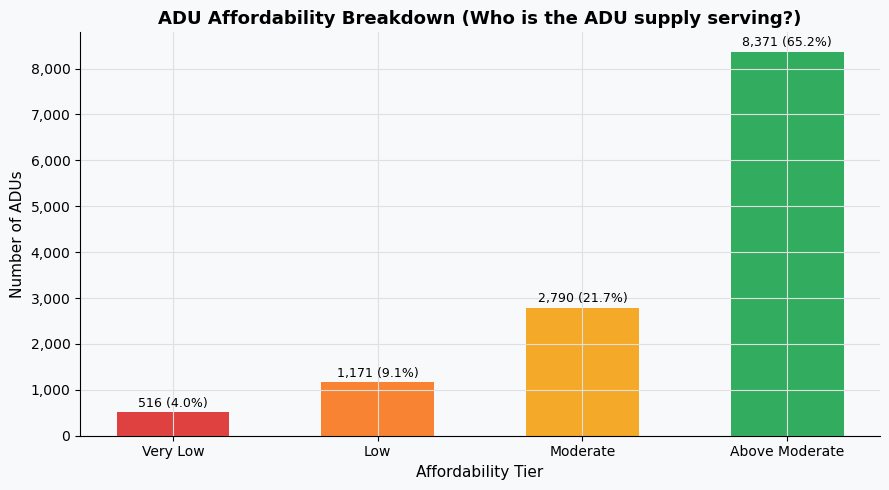

In [113]:
order = ['Very Low','Low','Moderate','Above Moderate']
colors = [RED,'#f97316',AMBER,GREEN]
counts = adu_df['AFFORDABILITY'].value_counts().reindex(order)
total = counts.sum()
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(order, counts.values, color=colors, alpha=0.88, width=0.55)
for bar, val in zip(bars, counts.values):
    pct = val/total*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('ADU Affordability Breakdown (Who is the ADU supply serving?)', fontweight='bold')
ax.set_xlabel('Affordability Tier'); ax.set_ylabel('Number of ADUs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

**Interpretation:** 65% of ADUs are Above Moderate (>120% AMI) — effectively market-rate. Only 4% are Very Low income. Zero deed-restricted affordable ADUs exist — every affordability classification is informal, not legally binding.

### Chart 3 — Affordability Mix Over Time

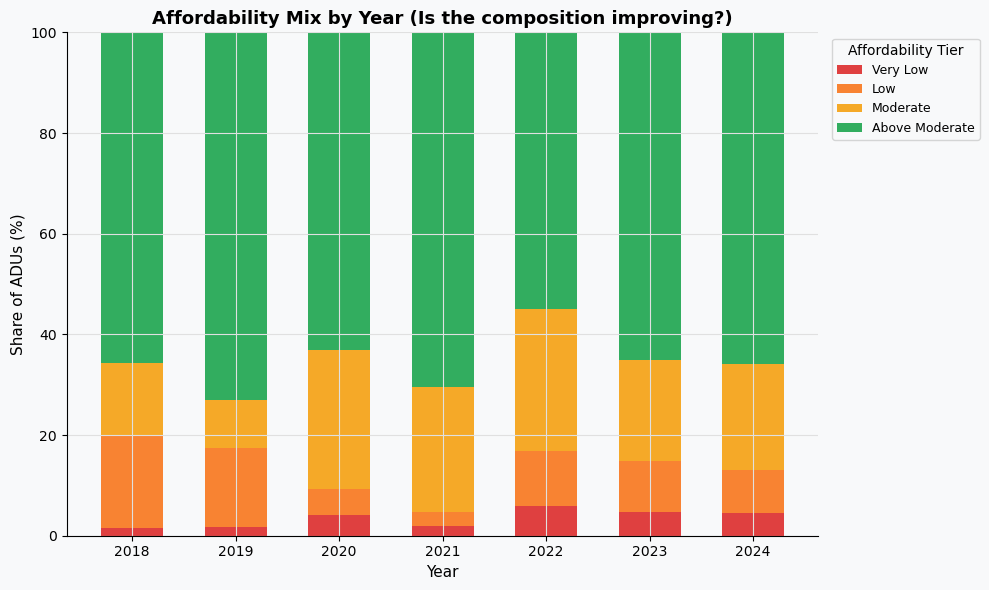

In [114]:
order = ['Very Low','Low','Moderate','Above Moderate']
colors = [RED,'#f97316',AMBER,GREEN]
aff_year = adu_df.groupby(['YEAR','AFFORDABILITY']).size().unstack(fill_value=0).reindex(columns=order)
aff_pct = aff_year.div(aff_year.sum(axis=1), axis=0)*100
fig, ax = plt.subplots(figsize=(10,6))
bottom = np.zeros(len(aff_pct))
for col, color in zip(order, colors):
    ax.bar(aff_pct.index, aff_pct[col], bottom=bottom, color=color, alpha=0.88, label=col, width=0.6)
    bottom += aff_pct[col].values
ax.set_title('Affordability Mix by Year (Is the composition improving?)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Share of ADUs (%)')
ax.set_ylim(0,100)
ax.legend(title='Affordability Tier', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** The affordability mix has been flat across all years — Above Moderate ADUs make up ~60-70% consistently. Legislative reform increased volume but did not shift the affordability profile.

### Chart 4 — Top Jurisdictions by ADU Count

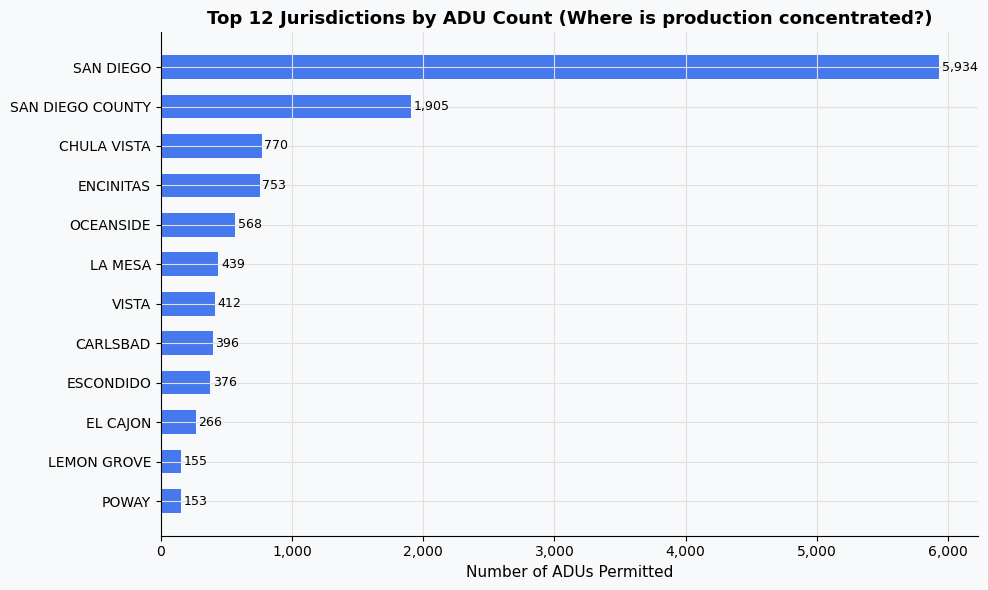

In [115]:
top_jurs = adu_df['JURISDICTION'].value_counts().head(12).sort_values()
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top_jurs.index, top_jurs.values, color=BLUE, alpha=0.85, height=0.6)
for bar, val in zip(bars, top_jurs.values):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 12 Jurisdictions by ADU Count (Where is production concentrated?)', fontweight='bold')
ax.set_xlabel('Number of ADUs Permitted')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

**Interpretation:** The City of San Diego alone accounts for 46% of all ADU permits — more than the next 5 jurisdictions combined. Smaller jurisdictions have minimal production, suggesting restrictive zoning, lower demand, or limited infill land.

### Chart 5 — Pipeline Completion Funnel

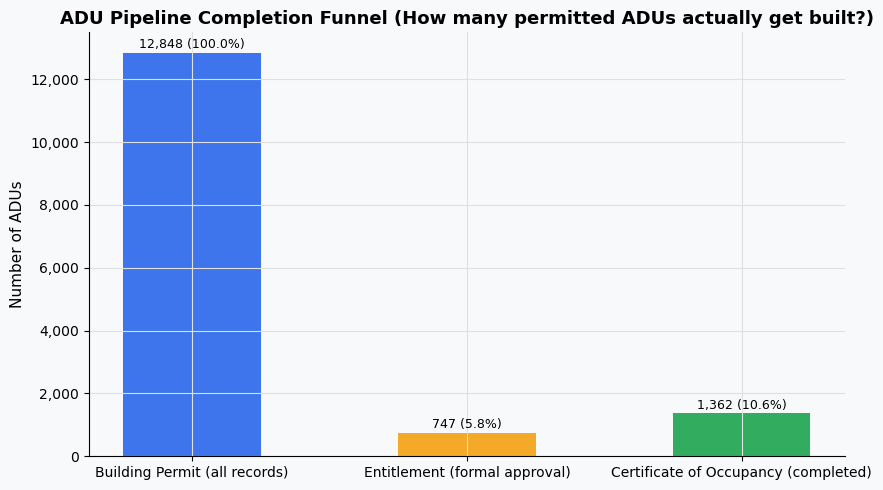

In [116]:
total = len(adu_df)
stages = {
    'Building Permit (all records)': adu_df['has_bp'].sum(),
    'Entitlement (formal approval)': adu_df['has_entitlement'].sum(),
    'Certificate of Occupancy (completed)': adu_df['has_co'].sum(),
}
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(stages.keys(), stages.values(), color=[BLUE,AMBER,GREEN], alpha=0.88, width=0.5)
for bar, val in zip(bars, stages.values()):
    pct = val/total*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('ADU Pipeline Completion Funnel (How many permitted ADUs actually get built?)', fontweight='bold')
ax.set_ylabel('Number of ADUs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

**Interpretation:** Only 1,362 (10.6%) have a recorded Certificate of Occupancy — 89% have no documented completion. This highlights a critical data gap: the state cannot reliably count occupiable ADUs, undermining housing supply accounting.

### Chart 6 — Tenure & Financial Assistance

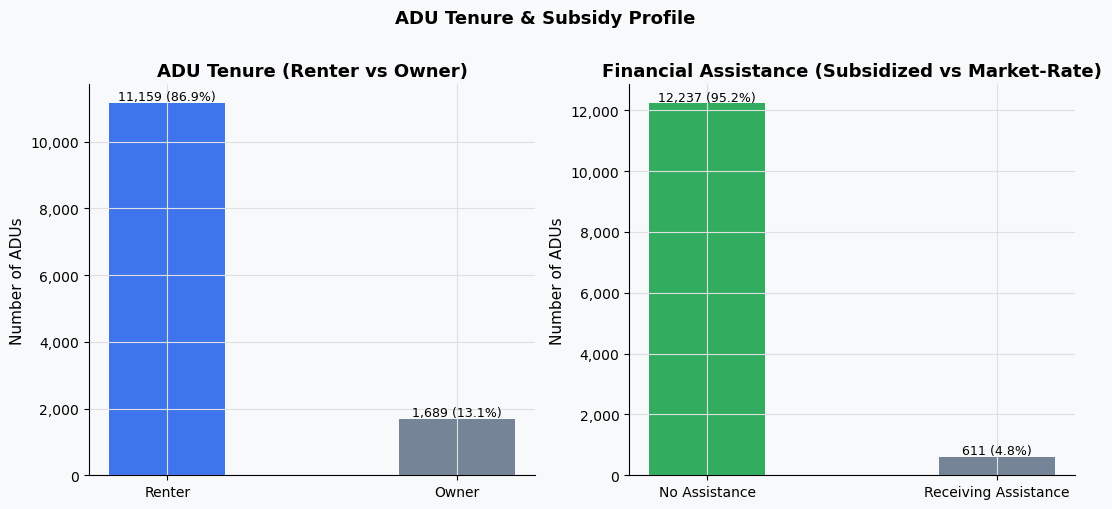

In [117]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
tenure_counts = adu_df['TENURE'].value_counts()
ax1.bar(tenure_counts.index, tenure_counts.values, color=[BLUE,GRAY], alpha=0.88, width=0.4)
for i,(label,val) in enumerate(tenure_counts.items()):
    pct = val/tenure_counts.sum()*100
    ax1.text(i, val+80, f'{val:,} ({pct:.1f}%)', ha='center', fontsize=9)
ax1.set_title('ADU Tenure (Renter vs Owner)', fontweight='bold')
ax1.set_ylabel('Number of ADUs')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
fa_counts = adu_df['fin_assist'].map({True:'Receiving Assistance',False:'No Assistance'}).value_counts()
ax2.bar(fa_counts.index, fa_counts.values, color=[GREEN,GRAY], alpha=0.88, width=0.4)
for i,(label,val) in enumerate(fa_counts.items()):
    pct = val/fa_counts.sum()*100
    ax2.text(i, val+80, f'{val:,} ({pct:.1f}%)', ha='center', fontsize=9)
ax2.set_title('Financial Assistance (Subsidized vs Market-Rate)', fontweight='bold')
ax2.set_ylabel('Number of ADUs')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.suptitle('ADU Tenure & Subsidy Profile', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Interpretation:** 87% of ADUs are renter-occupied. Only 4.8% receive financial assistance — ADU production is almost entirely market-driven with minimal public subsidy.

## Key Takeaways

The HCD ADU dataset tells a story of **impressive volume growth but persistent affordability failure**:

- **65% are market-rate** (Above Moderate), composition unchanged despite years of reform
- **Zero deed-restricted affordable ADUs** — affordability classifications are informal, not binding
- **Only 10.6% have a recorded CO** — critical data gap in pipeline completion tracking
- **87% renter-occupied**, adding rental supply but mainly for moderate-to-high earners
- **46% concentrated in City of San Diego**, smaller jurisdictions far behind

ADU reform unlocked supply volume but not affordable supply. Targeted subsidies and deed-restriction requirements are needed to shift production toward households that actually need help.